In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw03.ipynb")

# 📰 Homework 3: Text Analysis of New York Times Articles

### Due Date: Thursday, September 25, 11:59 PM

You must submit this assignment to Pensieve by the on-time deadline, **Thursday, September 25**, at 11:59 PM. Please read the syllabus for the Slip Day policy. No late submissions beyond what is outlined in the Slip Day policy will be accepted. **We strongly encourage you to submit your work to Pensieve several hours before the stated deadline.** This way, you will have ample time to reach out to staff for support if you encounter difficulties with submission. While course staff is happy to help guide you with submitting your assignment ahead of the deadline, we will not respond to last-minute requests for assistance.

Please read the instructions carefully when submitting your work to Pensieve.

## Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the homework, we ask that you **write your solutions individually**. If you do discuss the assignments with others, please **include their names** below.


**Collaborators**: _list collaborators here_


## 📝 This Assignment
Welcome to Homework 3! In this assignment, we will analyze New York Times articles discussing trending topics from the past six years.

You will gain experience with:

- Cleaning and exploring a text-based dataset,
- Manipulating data in `pandas` using `string` accessors,
- Creating and interpreting visualizations with `seaborn`,
- Writing and applying regular expressions (regex) with `pandas`, and
- Performing sentiment analysis on text using the `DistilBERT` language model.


In [2]:
# Run this cell to set up your notebook. 
import warnings
warnings.simplefilter(action="ignore")

import re
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ds100_utils import *

# Ensure that pandas shows at least 280 characters in columns, so we can see full articles.
pd.set_option("max_colwidth", 280)
plt.style.use("fivethirtyeight")
sns.set()
sns.set_context("talk")
sns.set_palette("colorblind")

In this assignment, we will use the [DistilBERT model](https://medium.com/huggingface/distilbert-8cf3380435b5), a Natural Language Processing (NLP) model designed to capture the context and meaning of words within sentences. While you are not expected to understand the intricate details of the model, we will utilize it to perform sentiment analysis on textual data. The necessary tools and the corresponding model are imported below.

## ⚠️ IMPORTANT NOTE

Due to limited computing resources on DataHub, the cell below **may take a significant amount of time to run** (potentially several minutes). This may also apply to other cells later in the assignment that load and use the NLP model.

This homework also uses a large dataset which can also cause some cells to take longer to run.

**Please be patient**, wait, and **avoid restarting the kernel or rerunning these cells** more than necessary. Doing so can slow down *your* notebook and impact *other students* on the same CPU cluster.

Additionally, **DO NOT** open this assignment in multiple tabs or windows. This can cause your notebook to crash and affect DataHub's performance.

Please be patient and seek assistance during Office Hours or on Ed if you encounter any issues!

Please also **ignore** any warning messages the code may output


In [4]:
from transformers import pipeline
model_checkpoint = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

### 💯 Score Breakdown

 Question | Manual| Points
--- |---| ---
1a |No| 1
1b |No| 1
1c |No| 1
2ai |No| 2
2aii |No| 1
2aiii |No| 2
2bi |No| 1
2bii |No| 1
2biii |Yes| 1
2c |No| 2
2d |No| 2
2e |No| 1
2fi |Yes| 1
2fii |Yes| 2
3a |No| 1
3b |Yes| 1
3ci |No| 1
3cii |Yes| 1
3d |Yes| 1
4 |Yes| 2
**Total** | **9** | **26**

## 🏎️ Before You Start

For each question in the assignment, please write down your answer in the answer cell(s) right below the question.

We understand that it is helpful to have extra cells breaking down the process towards reaching your final answer. If you happen to create new cells below your answer to run code, **NEVER** add cells between a question cell and the answer cell below it. It will cause errors when we run the autograder, and it will sometimes cause a failure to generate the PDF file.

**Important note: The local autograder tests will not be comprehensive. You can pass the automated tests in your notebook but still fail tests on Pensieve after the grades are released.** Please be sure to check your results carefully.

Finally, unless we state otherwise, **do not use for loops or list comprehensions**. The majority of this assignment can be done using built-in commands in `pandas` and `NumPy`.

### 🐛 Debugging Guide

If you run into any technical issues, we highly recommend checking out the [Data 100 Debugging Guide](https://ds100.org/debugging-guide/). In this guide, you can find general questions about Datahub, Pensieve, and common `pandas` and RegEx errors.


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 📊 Question 1: Importing the Data

The data for this assignment is sourced from the [New York Times (NYT) Archive API](https://developer.nytimes.com/docs/archive-product/1/overview), which provides information about articles published in the past.

The file `data/nyt_articles.txt` contains a random sample of filtered data of specific NYT articles published between 2019 and 2024 (inclusive). Each article discusses trending topics, which we will specify shortly.

<br>

---

### 📊 Question 1a

Let's examine the contents of the `data/nyt_articles.txt` file.

Using the [`open()` function](https://docs.python.org/3/library/functions.html#open) and the [`read()` method](https://docs.python.org/3/tutorial/inputoutput.html#methods-of-file-objects) of a `python` file object, read **the first 200 characters** of the file `data/nyt_articles.txt` and store the result in the variable `q1a`. Then, print the result to inspect it. This may take a few seconds to run.

**CAUTION:** Viewing the contents of large files in a Jupyter Notebook can crash your browser. Be careful not to print the entire contents of the file.

In [7]:
with open('data/nyt_articles.txt',mode='r') as f:
    q1a=f.read(200)

print(q1a)

{"web_url":{"0":"https:\/\/www.nytimes.com\/2020\/01\/01\/well\/move\/exercise-physical-activity-workout-time.html","1":"https:\/\/www.nytimes.com\/2020\/01\/01\/world\/europe\/pope-francis-slap-video


In [8]:
grader.check("q1a")

q1a results: All test cases passed!

<br>

---

### 📊 Question 1b

Based on the printed output from `q1a`, what format is the data in?

**A.** CSV<br/>
**B.** JavaScript Object Notation (JSON)<br/>
**C.** HTML<br/>
**D.** Excel (XLSX)

Answer in the following cell. Your answer should be a string, either `"A"`, `"B"`, `"C"`, or `"D"`, stored in the variable `q1b`.

**CAUTION:** Viewing the contents of large files in a Jupyter Notebook can crash your browser. Be careful not to print the entire contents of the file, and do not use the file explorer to open data files directly.

In [15]:
q1b = 'B'

In [16]:
grader.check("q1b")

q1b results: All test cases passed!

<br>

---

### 📊 Question 1c
`pandas` has built-in readers for many different file formats. To learn more about these, check out the documentation:

- `pd.read_csv` [(docs)](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)
- `pd.read_json` [(docs)](https://pandas.pydata.org/docs/reference/api/pandas.read_json.html)
- `pd.read_html` [(docs)](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_html.html)
- `pd.read_excel` [(docs)](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html)

Load the file `data/nyt_articles.txt` as a `DataFrame`, and store it in the variable `news_df`.

**Hint:** If your code is taking a while to run, you should review your answers to `q1a` and `q1b`; you may have used the incorrect data loading function.

In [17]:
news_df=pd.read_json('data/nyt_articles.txt')
news_df.head()

,web_url,pub_date,lead_paragraph
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do."
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne..."
3,https://www.nytimes.com/2020/01/01/world/europe/zoo-fire-krefeld-germany.html,2020-01-01T16:40:31+0000,"Three women who flew paper sky lanterns to celebrate the New Year are under investigation after a zoo fire in Krefeld, Germany, killed dozens of animals and burned down a primate enclosure, the police said Thursday."
4,https://www.nytimes.com/2020/01/01/parenting/money-rage-and-love.html,2020-01-01T17:20:06+0000,"Happy New Year! On this first day of 2020, I’m reflecting on the parenting stories that moved me from the past year. What I love about covering this beat is that how we raise children touches on every topic imaginable: Money, privilege, politics, race, business and technology..."


In [18]:
grader.check("q1c")

q1c results: All test cases passed!

<br/>

<hr style="border: 1px solid #fdb515;" />

##  📈 Question 2: Topic Trends Over Time

Now that we've loaded the NYT data, let's analyze trends in different topics. This will help us understand how various subjects have evolved over the years and identify any significant patterns or shifts in public interest.

We will start by extracting date and time information from the articles and then proceed to analyze the frequency and context of specific topics mentioned in the articles.


<br>


---

### 📈 Question 2a

In this question, we will process the `pub_date` column of our dataset to canonicalize time-related data.
This will help us investigate the trend of news articles across units of time like years, months, and seasons.

####  Question 2a, Part i

Create a new `DataFrame` called `dates` that contains:
1. The same index as `news_df`
2. Three columns: `Year`, `Month`, and `Minute`, which contain the year, month, and minute, respectively, that each article was published.

Additionally, convert all numerical values (`Year`, `Month`, `Minute`) to type `int`.

**Note:** For this problem, you are not permitted to use methods from the `Series.dt` accessor.

**Hint 1:** Use the `Series.str.extract` function ([documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.extract.html)).

**Hint 2:** Use raw strings and capture groups. You may find it helpful to copy the example date and time entries above into [regex101.com](https://regex101.com/) to experiment with regular expressions.

**Hint 3:** It might be helpful to break this up into a couple of steps (e.g., first extract date values and then extract time values).

In [25]:
time_series=news_df['pub_date']
time_series

0       2020-01-01T10:00:13+0000
1       2020-01-01T14:42:43+0000
2       2020-01-01T16:00:09+0000
3       2020-01-01T16:40:31+0000
4       2020-01-01T17:20:06+0000
                  ...           
8049    2022-12-05T15:00:07+0000
8050    2023-03-28T12:00:00+0000
8051    2021-07-16T13:04:51+0000
8052    2022-02-08T02:07:05+0000
8053    2020-09-01T20:14:30+0000
Name: pub_date, Length: 8054, dtype: object

In [37]:
time_series=news_df['pub_date']
dates=time_series.str.extract(r'^(.{4})-(.{2})-.{6}(.{2})')
dates=dates.rename(columns={0:'Year',1:'Month',2:'Minute'})
dates['Year']=dates['Year'].astype(int)
dates['Month']=dates['Month'].astype(int)
dates['Minute']=dates['Minute'].astype(int)
dates.head()

,Year,Month,Minute
0,2020,1,0
1,2020,1,42
2,2020,1,0
3,2020,1,40
4,2020,1,20


In [38]:
grader.check("q2ai")

q2ai results: All test cases passed!

---
####  Question 2a, Part ii

We aim to analyze topic trends over time by merging news article data with corresponding date and time data. 

Use the `pd.DataFrame.merge` [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) to merge the `dates` `DataFrame` with the `news_df` `DataFrame`. Ensure that `news_df` is the left `DataFrame` and `dates` is the right `DataFrame` in the merge operation.

Assign the merged `DataFrame` to a variable named `news_df_dates`.

In [40]:
news_df_dates = news_df.merge(right=dates,left_index=True,right_index=True)
news_df_dates.head()

,web_url,pub_date,lead_paragraph,Year,Month,Minute
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0
3,https://www.nytimes.com/2020/01/01/world/europe/zoo-fire-krefeld-germany.html,2020-01-01T16:40:31+0000,"Three women who flew paper sky lanterns to celebrate the New Year are under investigation after a zoo fire in Krefeld, Germany, killed dozens of animals and burned down a primate enclosure, the police said Thursday.",2020,1,40
4,https://www.nytimes.com/2020/01/01/parenting/money-rage-and-love.html,2020-01-01T17:20:06+0000,"Happy New Year! On this first day of 2020, I’m reflecting on the parenting stories that moved me from the past year. What I love about covering this beat is that how we raise children touches on every topic imaginable: Money, privilege, politics, race, business and technology...",2020,1,20


In [41]:
grader.check("q2aii")

q2aii results: All test cases passed!

#### Question 2a, Part iii

Add a column to `news_df_dates` called `Quarter` that contains the [fiscal quarter](https://www.investopedia.com/terms/q/quarter.asp#:~:text=The%20standard%20calendar%20quarters%20that,August%2C%20and%20September%20(Q3)) each news article was published.

Each value of `Quarter` should be in the format `"<Year>Q<Quarter Number>"`.

For example:
- A news article published in May 2021 will have its `Quarter` value as `"2021Q2"`.
- A news article published in October 2023 will have its `Quarter` value as `"2023Q4"`.

Do not hardcode the conversion from month to quarter (e.g., do not use the dictionary `{1: 'Q1', 2: 'Q1', ..., 12: 'Q4'}`). Instead, perform a mathematical operation to convert the month to quarter.

**Hint:** Adding two `Series` of strings (e.g., `ser_1 + ser_2`) performs an element-wise concatenation of their elements.

In [49]:
news_df_dates['Quarter']=news_df_dates['Year'].astype(str)+'Q'+news_df_dates['Month'].map(lambda x:(x-1)//3+1).astype(str)
news_df_dates

,web_url,pub_date,lead_paragraph,Year,Month,Minute,Quarter
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,2020Q1
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,2020Q1
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,2020Q1
3,https://www.nytimes.com/2020/01/01/world/europe/zoo-fire-krefeld-germany.html,2020-01-01T16:40:31+0000,"Three women who flew paper sky lanterns to celebrate the New Year are under investigation after a zoo fire in Krefeld, Germany, killed dozens of animals and burned down a primate enclosure, the police said Thursday.",2020,1,40,2020Q1
4,https://www.nytimes.com/2020/01/01/parenting/money-rage-and-love.html,2020-01-01T17:20:06+0000,"Happy New Year! On this first day of 2020, I’m reflecting on the parenting stories that moved me from the past year. What I love about covering this beat is that how we raise children touches on every topic imaginable: Money, privilege, politics, race, business and technology...",2020,1,20,2020Q1
...,...,...,...,...,...,...,...
8049,https://www.nytimes.com/2022/12/05/special-series/cinema-diversity-omar-sy.html,2022-12-05T15:00:07+0000,"This personal reflection is part of a series called Turning Points, in which writers explore what critical moments from this year might mean for the year ahead. You can read more by visiting the Turning Points series page.",2022,12,0,2022Q4
8050,https://www.nytimes.com/interactive/2023/us/mercer-north-dakota-covid-cases.html,2023-03-28T12:00:00+0000,"See the latest charts and maps of virus hospitalizations, cases, deaths, tests and vaccinations in Mercer County, North Dakota.",2023,3,0,2023Q1
8051,https://www.nytimes.com/interactive/2021/07/16/us/politics/guantanamo-bay-prison-gitmo.html,2021-07-16T13:04:51+0000,"Because of the pandemic, it had been 500 days since my last visit, but I finally made it back.",2021,7,4,2021Q3
8052,https://www.nytimes.com/2022/02/07/us/politics/eric-lander-resigns-white-house.html,2022-02-08T02:07:05+0000,"WASHINGTON — Eric S. Lander, the president’s top science adviser, resigned Monday evening after acknowledging that he had demeaned and disrespected his colleagues, behavior that prompted immediate questions about how he could keep his job given President Biden’s promise to fi...",2022,2,7,2022Q1


In [50]:
grader.check("q2aiii")

q2aiii results: All test cases passed!

<br>

---

### 📈 Question 2b

In this question, we will answer some EDA questions about `news_df_dates`.

####  Question 2b, Part i
In `news_df_dates`, suppose we create a new column `num_google_mentions` that records the number of times the word `"google"` is mentioned in each news article. What type of variable is `num_google_mentions`?

**A.** Qualitative Ordinal variable<br/>
**B.** Quantitative variable<br/>
**C.** Qualitative Nominal variable

Answer in the following cell. Your answer should be a string, either `"A"`, `"B"`, or `"C"`, stored in the variable `q2bi`.

In [51]:
q2bi = 'A'

In [52]:
grader.check("q2bi")

q2bi results: All test cases passed!

####  Question 2b, Part ii
Which of the following options best describes the granularity of `news_df_dates`? 

Each row in `news_df_dates` uniquely describes:

**A.** A news article. <br/>
**B.** A calendar date. <br/>
**C.** An hour of a calendar date. 


Answer in the following cell. Your answer should be a string, either `"A"`, `"B"`, or `"C"`, stored in the variable `q2bii`.

In [53]:
q2bii = 'A'

In [54]:
grader.check("q2bii")

q2bii results: All test cases passed!

<!-- BEGIN QUESTION -->

####  Question 2b, Part iii

Suppose we wanted to investigate trends in how often the word `"AI"` is mentioned in NYT articles since the 1980s.

Is `news_df` a suitable dataset for this investigation? Explain your reasoning.

_No. Firstly, the new_df dataframe doesn't have a column that indicates the published year directly, so necessary preparation is to be done. Secondly, the dataframe only extracts the first paragraph of the article, so it doesn't fully reflect how often the word 'AI' was used._

<!-- END QUESTION -->

<br>

---

###  📈 Question 2c

Some news articles include quotes in their lead paragraph (i.e., first paragraph) to grab the reader's attention and provide additional context. For the purposes of this question, a quote is defined as a sequence of characters starting with the character `"` and ending with a period (`.`), question mark (`?`), or exclamation point (`!`), followed by a closing `"`. For example:
- `"The mitochondria is the powerhouse of the cell!"`
- `"Did DATA C100 course staff host a social event with staff from DATA C8?"`
- `"R is great." A TA said, "but have you tried using Python?"`

If we follow the definition above, the following text snippet contains two quotes:
- `The TA asked, "What's the purpose of regular expressions?" The student thought for a moment and then replied, "Regex are used to identify patterns in text."`



Brandon wants to extract individual quotes from paragraphs using the definition of a quote given above.
Brandon proposes the regex pattern `r'\".*[\.\?\!]\"'`. Unfortunately, Brandon's pattern identifies only one quote in the test string below instead of two.

Modify Brandon's regex pattern so that it correctly matches the two quotes individually. Store your new pattern in the variable `modified_pattern`.

In [55]:
test_string = '"How are your classes?" the student asked. "Super challenging! But a lot of fun!" said their roommate.'

print("Test string:", test_string)
print("Original pattern identifies:", re.findall(r'\".*[\.\?\!]\"', test_string))

modified_pattern = r'\".*?[\.\?\!]\"'
print("Modified pattern identifies:", re.findall(modified_pattern, test_string))

Test string: "How are your classes?" the student asked. "Super challenging! But a lot of fun!" said their roommate.
Original pattern identifies: ['"How are your classes?" the student asked. "Super challenging! But a lot of fun!"']
Modified pattern identifies: ['"How are your classes?"', '"Super challenging! But a lot of fun!"']


In [56]:
grader.check("q2c")

q2c results: All test cases passed!

<br>

---

### 📈 Question 2d

Before we continue our analysis, we'd like to introduce **[word boundaries](https://www.regular-expressions.info/wordboundaries.html)** Word boundaries prevent matches within a word (i.e. if you are trying to match "article", it will prevent matches from existing with "articles" or "particle"). Run the next cell to see word boundaries in action.

In [58]:
# Feel free to experiment with your own patterns and string using the \b

example_pattern = r"\barticle\b"

example_string_1 = "particle"
example_string_2 = "articles"
example_string_3 = "article"

print(f"Mathces in {example_string_1}: {re.findall(example_pattern, example_string_1)}")
print(f"Mathces in {example_string_2}: {re.findall(example_pattern, example_string_2)}")
print(f"Mathces in {example_string_3}: {re.findall(example_pattern, example_string_3)}")

Mathces in particle: []
Mathces in articles: []
Mathces in article: ['article']


Next, we will investigate popularity trends of the following three topics: [New Year](https://en.wikipedia.org/wiki/New_Year), [Zoom](https://www.zoom.com/), and [GPT models](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer).

For each topic, add an integer column to `news_df_dates` indicating the number of times the topic is mentioned in the `lead_paragraph` (i.e., first paragraph) of each article. 

- The columns should be named `"New Year"`,  `"Zoom"`, and `"GPT Model"`.

- You may use a `for` loop to iterate over a list of the three topics.

Here are the definitions of a single "mention" of each topic:
- **New Year**: An appearance of `"New Year"` or `"New Years"`, surrounded by *word boundaries*, in the lead paragraph of the article. For example, `"Happy New Year!"` is a match. Note, however, `new year` or `new years` **are not** matches.
- **Zoom**: `"Zoom"`, surrounded by *word boundaries*. For example, `"Zoomer"` would not match. Similarly, `zoom` **would not match**.
- **GPT Model**: either (1) a consecutive sequence of alphabetical characters, followed by an optional dash (`-`), then `GPT`; or (2) `GPT`, then a dash (`-`), then a numeric digit, then an optional alphabetical character. Finally, surround this with *word boundaries*.
    - For example, these words match: `"ChatGPT"`, `"CHAT-GPT"`, `"GPT-3"`, `"GPT-4o"`.
    - However, these words do not match: `"chatgpt"`, `"chatgpt-4o"`.

If you're unsure how to design the regex patterns to match these cases, feel free to use [https://regex101.com/](https://regex101.com/)! You can test the patterns you've come up with and paste in a paragraph to see if your pattern correctly extracts all instances of the word blocks you're targeting.

**Note**: in this question we recommend using **[word boundaries](https://www.regular-expressions.info/wordboundaries.html)** in your regex pattern.

In [81]:
news_df_dates['New Year']=news_df_dates['lead_paragraph'].str.count(r'\bNew Years?\b')
news_df_dates['Zoom']=news_df_dates['lead_paragraph'].str.count(r'\bZoom\b')
news_df_dates['GPT Model']=news_df_dates['lead_paragraph'].str.count(r'\b(?:[A-Za-z]+-?GPT|GPT-\d+[A-Za-z]?)\b')
news_df_dates.head(1)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,Quarter,New Year,Zoom,GPT Model
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,2020Q1,1,0,0


In [82]:
grader.check("q2d")

q2d results: All test cases passed!

<br>

---

### 📈 Question 2e

Create a new `DataFrame` called `topic_mentions` with the following characteristics:

- There should be one column for each topic (`"New Year"`,  `"Zoom"`, and `"GPT Model"`).

- The index should be `Quarter`.

- The values are the number of articles that mentioned each topic in each quarter. 

**Hint**: Define a helper function `num_mentioned(ser)`, which takes a `Series` object `ser` and returns the number of entries in `ser` that are larger than `0`.

In [83]:
topics = ["New Year", "Zoom", "GPT Model"]

topic_mentions=news_df_dates.groupby('Quarter').agg({'New Year':'sum','Zoom':'sum','GPT Model':'sum'})

# Year 2023 records
topic_mentions[16:20]

,New Year,Zoom,GPT Model
Quarter,,,
2023Q1,62,16,47
2023Q2,4,8,24
2023Q3,2,6,30
2023Q4,25,4,27


In [84]:
grader.check("q2e")

q2e results: All test cases passed!

<!-- BEGIN QUESTION -->

<br>

---
### 📈 Question 2f

Let's visualize the article counts for each topic by quarter from 2019 to 2024.

#### Question 2f, Part i

Using `sns.lineplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.lineplot.html)) and `topic_mentions`, visualize the topic trends across quarters. Your plot should look like this:

 **Hint**: If you notice that your graph looks significantly different from the one we've presented, please go back and check your answer to Question 2d!

<center>
    <img src="./images/topic_mentions.png" width="750" align="left">
</center>

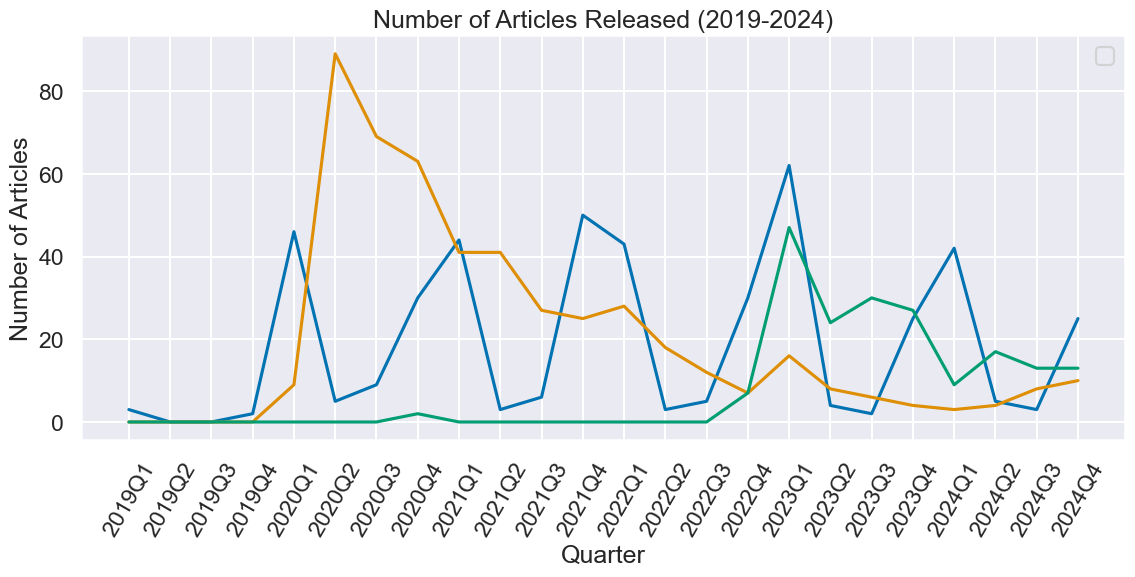

In [87]:
plt.figure(figsize=(12, 5)) # DO NOT MODIFY

for topic in topics:
    plt.plot(topic_mentions.index,topic_mentions[topic])
# DO NOT MODIFY THE CODE BELOW
# If your solution above is correct, running this cell should produce the plot above.
plt.xticks(rotation=60)
plt.yticks()
plt.ylabel("Number of Articles")
plt.xlabel("Quarter")
plt.title("Number of Articles Released (2019-2024)")
plt.gcf().set_facecolor('white')
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

####  Question 2f, Part ii

For each of the three topics, identify one interesting pattern in the visualization and provide a tentative explanation of why you think the pattern exists.


_New Year :mentions peak at the beginning of each year, as expected due to the holiday.
Zoom: 2020Q2 witnessed its peak. Because of the outbreak of COVID-19, the online meeting app Zoom's mentions surged up.
GPT Model: in 2023Q1 reached its peak, for the appearance of ChatGPT which went viral across the world._

<!-- END QUESTION -->

<br/>

<hr style="border: 1px solid #fdb515;" />

## ⁉️ Question 3: Sentiment Analysis

**Sentiment analysis** involves using an NLP model to classify the emotional tone of text. For example, "You're great!" has a positive sentiment, while "I feel horrible" has a negative sentiment.

In this section, we will explore temporal changes in the **sentiment** of NYT articles that mention each topic.

> The sentiment values in this section were computed using a fine-tuned version of the **DistilBERT** model ([original paper](https://arxiv.org/abs/1910.01108)).
>
> DistilBERT is a neural network-based language model similar to ChatGPT. These models are not covered in Data 100, and we don't expect you to know how they work. If you're interested in learning more, consider taking `CS182: Neural Networks` or `Data 102: Data, Inference, and Decisions`.
>
> The [HuggingFace library](https://huggingface.co/) was used to build the sentiment analysis pipeline and load the model. [Here](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english) is the **model card** of the `DistilBERT` model we used. The model card contains general information about the model, such as training arguments and training data. Again, you don't need to know these details for Data 100!

Run the following cells to set up the sentiment analysis pipeline and see examples of how we can get the sentiment for different strings.

**Note**: you may receive some warning message. Feel free to ignore this.


In [88]:
# Load the model
sentiment_analysis = pipeline("sentiment-analysis", model=model_checkpoint)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [89]:
# Get the sentiment of a given string
sentiment_1 = sentiment_analysis("I have two dogs.")
print("Example 1: " + str(sentiment_1))

sentiment_2 = sentiment_analysis("I do not have dogs.")
print("Example 2: " + str(sentiment_2))

sentiment_3 = sentiment_analysis("Fortunately, I do not have dogs to worry about.")
print("Example 3: " + str(sentiment_3))

Example 1: [{'label': 'POSITIVE', 'score': 0.9955033659934998}]
Example 2: [{'label': 'NEGATIVE', 'score': 0.9987561702728271}]
Example 3: [{'label': 'POSITIVE', 'score': 0.9975079298019409}]


As you can see, the model can determine the sentiment of phrases/sentences (not just words). The model measures the phrase's **polarity**, indicating how strongly negative or positive it is on a scale of 0 to 1.

**Note:** The output is a list, and each list element is a dictionary with two keys (label and score). Note that we could have gotten the sentiments of the two sentences by putting them in a list (batch) and then running the pipeline once (see the code below).


<br>

---
### ⁉️ Question 3a

Try it out yourself! The sentences we provided in the previous example have pretty high polarity scores. Let's see how the model behaves with more ambiguous sentences.

Write a sentence `less_polar_sentence` that has a polarity score of less than 0.8. This may take some trial and error. Let this be an opportunity to think about whether the model works as you'd expect.

In [91]:
less_polar_sentence = 'There is a fussy cat.'
results = sentiment_analysis(less_polar_sentence)
print(results)

[{'label': 'NEGATIVE', 'score': 0.5079906582832336}]


In [92]:
grader.check("q3a")

q3a results: All test cases passed!

<br>

---

### Getting the Sentiment Data

Having all 1000+ students in Data 100 run the `DistilBERT` model for all articles is too computationally intensive for DataHub. So, we have done this part for you.

1. We have loaded the sentiment scores from `nyt_sentiments.csv`.
2. We have added a new column called `article_sentiment` that provides the existing score if the label is "POSITIVE", and negates the existing score if the label is "NEGATIVE". For example, a score of `0.6` with a label `POSITIVE` would have the value `0.6` in `article_sentiment`, while a score of `0.6` with a label `NEGATIVE` would have the value `-0.6` in `article_sentiment`.
3. We have merged `news_df_dates` with `sentiment` using the `web_url` column. The merged `DataFrame` is called `news_df_sentiment`.

In [93]:
# DO NOT EDIT THIS CELL
sentiment = pd.read_csv("data/nyt_sentiments.csv")

sentiment["article_sentiment"] = (
    (2*(sentiment["label"] == "POSITIVE") - 1) * sentiment["score"]
)
news_df_sentiment = news_df_dates.merge(sentiment, on="web_url")
news_df_sentiment = news_df_sentiment.drop(columns=["label", "score"])

Take a look at this new `DataFrame` called `news_df_sentiment`.

In [94]:
news_df_sentiment.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,Quarter,New Year,Zoom,GPT Model,article_sentiment
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,2020Q1,1,0,0,0.986820
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,2020Q1,1,0,0,-0.992706
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,2020Q1,1,0,0,-0.997801


Now, to continue our analysis from Question 2, let's focus on the articles that mention `Zoom`, `New Year`, or `GPT`. We have created a filtered `DataFrame` called `news_df_filtered` that contains all the information from `news_df_sentiment` with only the articles that mention `Zoom`, `New Year`, or `GPT`. Using the same definitions as Q2d.

In [95]:
news_df_filtered = news_df_sentiment[((news_df_sentiment['Zoom'] > 0) | news_df_sentiment['New Year'] > 0) | (news_df_sentiment['GPT Model'] > 0)]

Take a look at this new `DataFrame` called `news_df_filtered`.

In [96]:
news_df_filtered.head(3)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,Quarter,New Year,Zoom,GPT Model,article_sentiment
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,2020Q1,1,0,0,0.986820
1,https://www.nytimes.com/2020/01/01/world/europe/pope-francis-slap-video.html,2020-01-01T14:42:43+0000,ROME — Pope Francis apologized on Wednesday for the flash of anger — or self-protection — that he exhibited while greeting the faithful around the Vatican’s giant Nativity scene after a New Year’s Eve liturgy the evening before.,2020,1,42,2020Q1,1,0,0,-0.992706
2,https://www.nytimes.com/2020/01/01/opinion/north-korea-nuclear-test.html,2020-01-01T16:00:09+0000,"Is anyone surprised? On the last day of 2019, after months of threatening the United States to ease its nuclear standoff with ""a bold decision"" by year’s end — or else — the leader of North Korea darkly announced that the country would unveil a new strategic weapon ""in the ne...",2020,1,0,2020Q1,1,0,0,-0.997801


<!-- BEGIN QUESTION -->

<br>

---
### ⁉️ Question 3b

Let's now visualize the distribution of article sentiment.

Using `seaborn`, we created a histogram to visualize the distribution of `article_sentiment`. Run the cell below to display the plot.

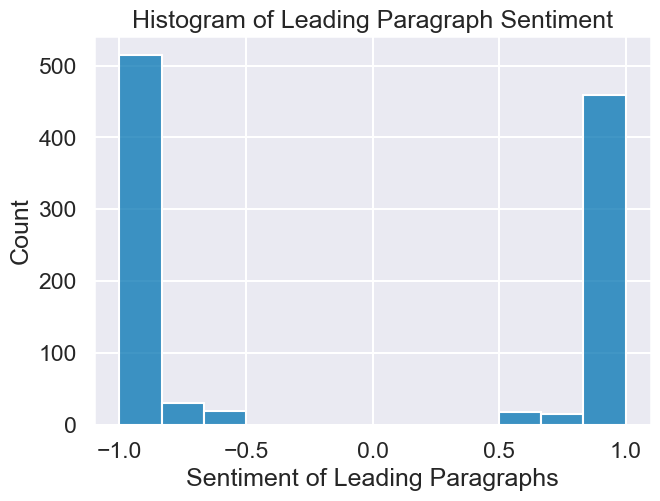

In [97]:
sns.histplot(data=news_df_filtered, x='article_sentiment')
plt.xlabel('Sentiment of Leading Paragraphs')
plt.title('Histogram of Leading Paragraph Sentiment')
plt.plot();

Are you at all surprised by the distribution of sentiment in the graph above? Describe what you notice about the graph.

_Both negative and positive sentiment of leading paragraphs have scores higher than 0.5, indicating there's a strong emotional preference in the paragraphs. This is probably because the aim of the first paragraphs is to attract readers' attention and express its statement clearly._

<!-- END QUESTION -->

<br>

---
### ⁉️ Question 3c

Let's audit our data to better understand how well the sentiment analysis model works with our specific dataset. It's good practice to compare our assumptions to model outputs.

####  Question 3c, Part i

Using `news_df_filtered`, assign `top_positive` and `top_negative` to `DataFrame`s containing the five articles with the highest `article_sentiment` values and the five lowest `article_sentiment` values, respectively. The `DataFrame`s should have the columns `lead_paragraph` and `article_sentiment`.

In [98]:
news_df_filtered.head(1)

,web_url,pub_date,lead_paragraph,Year,Month,Minute,Quarter,New Year,Zoom,GPT Model,article_sentiment
0,https://www.nytimes.com/2020/01/01/well/move/exercise-physical-activity-workout-time.html,2020-01-01T10:00:13+0000,"If, like many of us, your New Year’s resolution is to find more time to exercise, you may be in luck. According to a recent study of how Americans typically spend their waking hours, almost all of us have far more leisure time available than we think we do.",2020,1,0,2020Q1,1,0,0,0.98682


In [102]:
top_positive = news_df_filtered[news_df_filtered['article_sentiment']>0].sort_values(by='article_sentiment',ascending=False).head(5)[['lead_paragraph','article_sentiment']]
top_negative = news_df_filtered[news_df_filtered['article_sentiment']<0].sort_values(by='article_sentiment').head(5)[['lead_paragraph','article_sentiment']]

display(top_positive, top_negative)

,lead_paragraph,article_sentiment
941,"Happy New Year, audiophiles!",0.999876
381,"It’s easy to think about Twyla Tharp and immediately picture her body of work. It’s impressive. Tharp has choreographed more than 150 dances for just about every surface and site imaginable: the concert stage, parks, Broadway, film, ice and now Zoom.",0.999872
507,"Merry Christmas, happy Hanukkah, joyous Kwanzaa and happy New Year.",0.999871
661,"Merry Christmas, happy Hanukkah, joyous Kwanzaa and happy New Year.",0.999871
561,Happy New Year!,0.999869


,lead_paragraph,article_sentiment
862,"The day after Labor Day has got to be one of the worst days in the American calendar year. (Not quite as bad as the first workday after New Year’s, but worth mentioning in the same breath.)",-0.999777
94,"One day this quarantine, who can say which, I encountered the following pieces of information: Zoom, the videoconferencing company, saw its stock hit a new high; Zūm, a ride-sharing venture, cut its work force by a third; and Zume, the robot pizza start-up, failed to raise mo...",-0.999759
183,"In the beginning there was Covid-19, and the tribe of the white collars rent their garments, for their workdays were a formless void, and all their rituals were gone. New routines came to replace the old, but the routines were scattered, and there was chaos around how best to...",-0.999729
982,"There’s a problem with leading artificial intelligence tools like ChatGPT, Gemini and Claude: We don’t really know how smart they are.",-0.999702
192,"I was in Brooklyn on a Zoom meeting in mid-March, when I saw my mom’s name come up on my cellphone. ""Your dad’s not feeling well,"" she said.",-0.999698


In [103]:
grader.check("q3ci")

q3ci results: All test cases passed!

<!-- BEGIN QUESTION -->

####  Question 3c, Part ii

Do you agree with the current sentiment-based ordering of news articles, or would you rearrange the ordering? Do you feel that the DistilBERT model is a good model for our task of analyzing sentiment in news articles?

_In case of negative ones, the model does analyze some negative news, both for indivisuals and the society. But in terms of the positive news, it mostly notice those blessing which might not offer any help in following analysis._

<!-- END QUESTION -->

<br>

---

### Continued Visualizing
Let's continue to visualize the `news_df_filtered` data. The cell below adds a new datetime column `date` to `news_df_filtered`. The datetime format will make visualization easier.

In [104]:
# Combine the columns into a single date string in 'YYYY-MM-DD' format
news_df_filtered['date_str'] = (
    news_df_filtered['Year'].astype(str)
    + '-' + news_df_filtered['Month'].astype(str)
    + '-' + news_df_filtered['pub_date'].str[8:10]
)

# Convert the combined string to a datetime object using pd.to_datetime()
news_df_filtered['date'] = pd.to_datetime(news_df_filtered['date_str'], format='%Y-%m-%d', errors='coerce')

Below, we visualize the change in sentiment in the topic `Zoom` over time, using `sns.lineplot` to plot `date` on the x-axis and `article_sentiment` on the y-axis.

**Note**: If the following plot is empty, please rerun from all cells starting from Part 3b where `news_df_sentiment` was initialized.

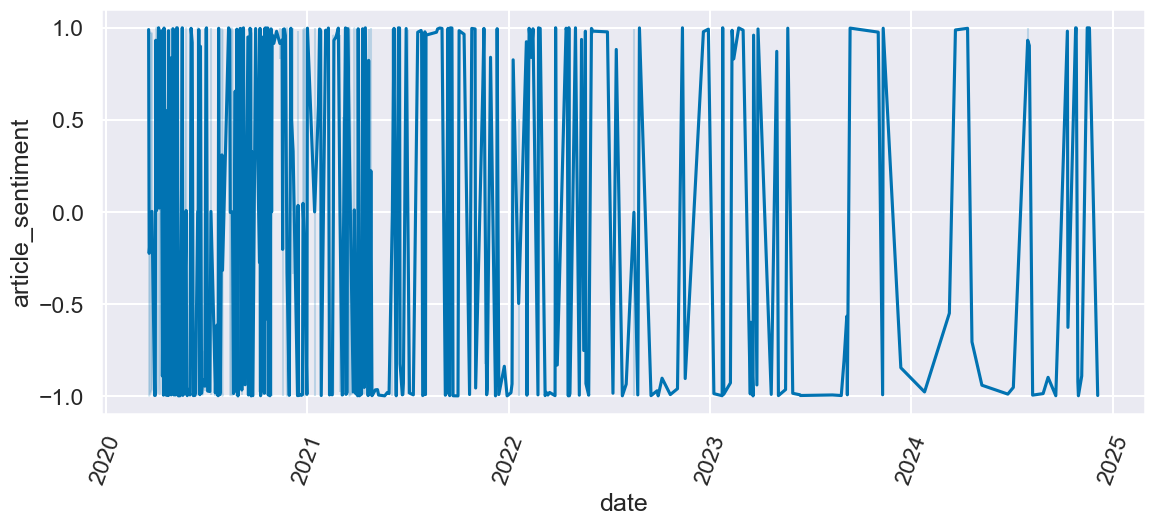

In [105]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=news_df_filtered[news_df_filtered["Zoom"] > 0], x='date', y='article_sentiment')
plt.xticks(rotation=70);

**This plot is not very pretty!** This isn't because of any errors on your part. Instead, we need to use a different visualization method to understand our data.

<!-- BEGIN QUESTION -->

### ⁉️ Question 3d

Let's visualize our data more effectively. We will still use `sns.lineplot`, but instead of plotting every observation, we will first aggregate our data, and then plot the aggregated values. We will compare sentiment scores across three topics: `New Year`, `Zoom`, and `GPT`.

You do not need to do anything, just run the code cell below.

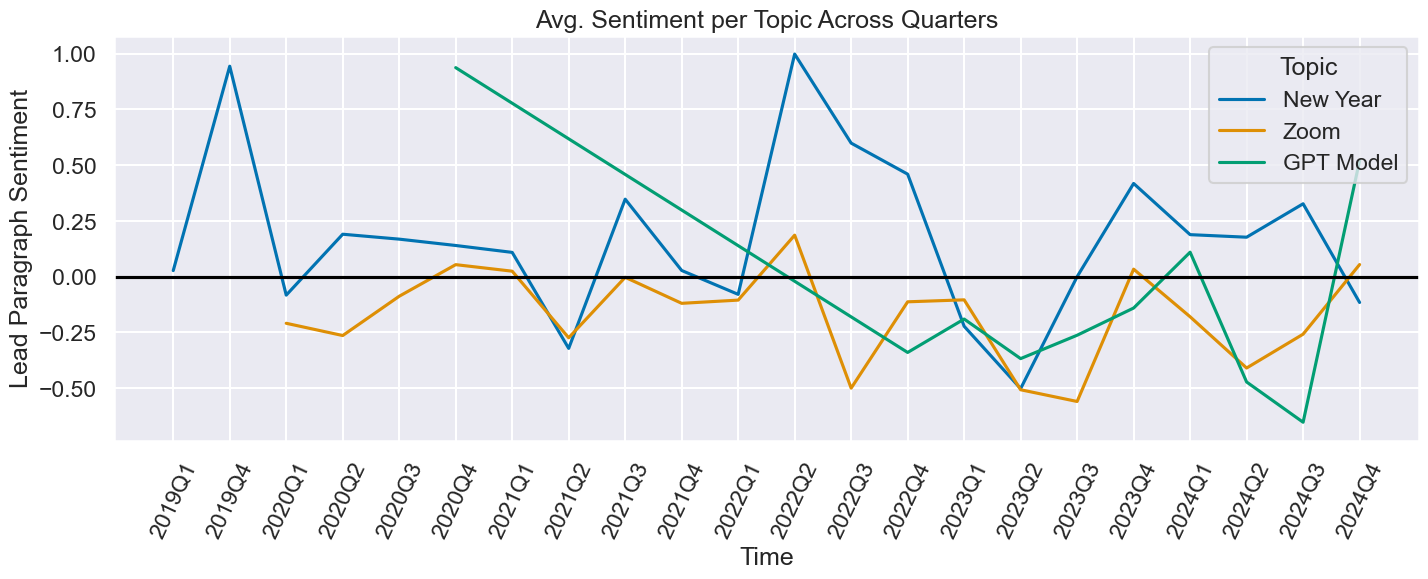

In [106]:
fig, ax = plt.subplots(figsize=(15, 5))
dfs_per_topic = []

for topic in topics:
    df_of_current_topic = news_df_filtered[news_df_filtered[topic] > 0].groupby("Quarter")["article_sentiment"].mean().reset_index()
    df_of_current_topic["Topic"] = topic
    dfs_per_topic.append(df_of_current_topic)

all_topic_qtr_avg_sentiments = pd.concat(dfs_per_topic)
sns.lineplot(data=all_topic_qtr_avg_sentiments, x="Quarter", y="article_sentiment", hue="Topic")

plt.title('Avg. Sentiment per Topic Across Quarters')
plt.xlabel('Time')
plt.ylabel('Lead Paragraph Sentiment')

plt.axhline(0, color='black')
plt.xticks(rotation=65);

In 1 sentence, identify one interesting pattern in the visualization (you do **not** need to explain why this pattern exists).

_The GPT Model line starts above zero, then dips below, before rising again at last._

<!-- END QUESTION -->

<br/>

---

# 🤖 Question 4: Open-Ended Question

Welcome to another **open-ended question**. Like Josh mentioned in Lecture 1, this semester we are piloting **open-ended homework questions** to provide you with new opportunities to think creatively as data scientists.  


> If you have any feedback on this open-ended question, or any other homework question in Data 100, we encourage you to share your thoughts using the [content feedback form](https://docs.google.com/forms/d/e/1FAIpQLScGQhiTz1qn5gsyYUu1Be5Yz0Z_kplIRR_os8UGMOAO8cc-yQ/viewform). You can also post to Ed.

Grading on open-ended questions is simple: **Clear evidence of thoughtfulness and effort will always receive full credit**. If your response is especially well-developed or creative, we may ask for permission to share it with the rest of the class so others can be inspired by your work! Underdeveloped ideas will receive half credit. Trivial or missing responses will receive no credit. We expect the vast majority of students to receive full credit.

**SETUP**: You are a data scientist working for the New York Times. Your manager is concerned that the New York Times exhibits **bias** in its articles and asks you to look into this.

**TASK**: Your task is to provide evidence for or against the hypothesis that the New York Times exhibits **bias** in its articles.

> Food for thought: Assume your manager has a ChatGPT Pro subscription and could easily ask the question above without reaching out to you for help. What's your added value over their ChatGPT Pro subscription? 

> Also, you might be wondering: What is the definition of "**bias**"? This is up to you to define and defend. There is no single correct answer. You might also be wondering: Who is the subject of the "**bias**"? Once again this is up to you to define.  Feel free to pick a domain that is interesting to you. Remember that a major part of data science is defining what success actually means.

For this task, you may use: 
- The `news_df_sentiment` `DataFrame`.
- Any `pandas`, `regex`, `matplotlib`, `seaborn` covered in class.
- (Optional) External resources (e.g., AI/LLMs, websites, datasets, or other Python libraries/packages).


Important exception to existing course policies: **<u>FOR THIS QUESTION ONLY</u>**, you are allowed to [vibe code](https://en.wikipedia.org/wiki/Vibe_coding). In other words, the code you use to generate responses can be generated by a large-language model (LLM), like Gemini or ChatGPT. However, the most important component of this question is not the code—it's the presentation and persuasiveness of your results. **If you copy-and-paste default output from an LLM on this question, there is a good chance that your submission will look identical or near-identical to many other students**. While we expect many answers to this question to have similarities, obvious default output will receive no credit. Spend time thinking about the presentation of your results. 

> Remember that Gemini Pro is free for students for one year, so long as you [sign up before October 6th](https://gemini.google/students/)!

> **Disclaimer**: As Data Science students, you should be aware of important limitations and broader considerations when it comes to the use of LLMs. 
> - LLMs do not guarantee factual accuracy and they are known to hallucinate (generate fabricated or misleading information). 
> - LLMs are trained on large datasets that can reflect and reproduce biases in race, gender, culture, and ideology. 
> - The use of LLMs may involve the sharing of sensitive and personal information, 



**Your answer should consist of the following**:
1. A **single visualization**. The contents of this visualization are ultimately up to you. As a starting point, you might think about how you can reflect your chosen definition of "**bias**". 
2. A write up of 3–10 sentences stating your definition of "**bias**", your answer to the hypothesis, and an explanation of why you have come to this conclusion. Your explanation must reference the visualization. Make it obvious and clear why your visualization supports your conclusion.

**Note**: For this question we are **not** accepting `DataFrame`s as visualizations.

> Keep in mind that your manager is interested in your answer to the hypothesis and the evidence you collected to support that recommendation. Don't spend more than a sentence or two explaining how you generated your visualization (e.g., no need to write "I used the X library to construct the Y-axis in my visualization."). 


> Focus on answering your manager's question, rather than explaining the detailed steps needed to answer the question (e.g., "The Y-axis in my visualization shows Z, which is why I concluded X.").


> **IMPORTANT**: If you have any questions, please read through the [**FAQS**](https://docs.google.com/document/d/1DLzA-kaj1n87uqcImwquBOLUcXBSF6JIoY2PMywwdhU/edit?usp=sharing) first. If you can't find the answer to your question there, feel free to ask your question on Ed.

### SUBMISSION INSTRUCTIONS

**Please read these carefully**
1. In the 2 scratch cells below, feel free to write any code you need to create your **single visualization**.
2. Once you are happy with your visualization, remove anytime you wrote `plt.show()` as this prevents the visualization from being saved as an image.
> `plt.savefig("final_viz.png", dpi=300, bbox_inches="tight")` at the bottom of scratch cell 2 saves your visualization to `final_viz.png`.
3. Run the scratch cells one last time without `plt.show()`.
4. **Comment out all code** in both scratch cells. **Including** `plt.savefig("final_viz.png", dpi=300, bbox_inches="tight")`.
5. Run the next cell to display your visualization. Make sure this is the correct visualization you want as part of your final deliverable.
6. Set `commented_out` to `True`.
7. In the markdown cell, complete your write-up in 3–10 sentences.

**Note**: `news_df_sentiment` is a very large `DataFrame`. If you run into memory issues, try to filter some rows or columns before running any complex functions. Please do not make multiple copies of `news_df_sentiment` as this may also cause memory issues. If you run into an memory issues please feel free to post on Ed or come to OH.

<!-- BEGIN QUESTION -->



In [154]:
# SCRATCH CELL 1
# (Optional) Feel free to import any extra libraries or packages here
# However, you do not need to import any extra libraries to answer the question and receive full credit
# Remember to comment out your code for step 3
#news_df_sentiment['Asian']=news_df_sentiment['lead_paragraph'].str.count(r'\bAsian\b')
#Asian_only=news_df_sentiment[news_df_sentiment['Asian']>0]
#news_df_sentiment['European']=news_df_sentiment['lead_paragraph'].str.count(r'\bEuropean\b')
#European_only=news_df_sentiment[news_df_sentiment['European']>0]

#Asian=Asian_only.groupby('Quarter').agg(sentiment=('article_sentiment','mean'))
#European=European_only.groupby('Quarter').agg(sentiment=('article_sentiment','mean'))

#all_quarters = pd.date_range(start='2020-01-01', end='2023-12-31', freq='Q').to_period('Q').astype(str)

#all_quarters = ['2019Q1','2019Q2','2019Q3','2019Q4','2020Q1','2020Q2','2020Q3','2020Q4',
                '2021Q1','2021Q2','2021Q3','2021Q4',
                '2022Q1','2022Q2','2022Q3','2022Q4',
                '2023Q1','2023Q2','2023Q3','2023Q4','2024Q1','2024Q2','2024Q3','2024Q4']

#Asian = Asian.reindex(all_quarters, fill_value=0).reset_index()
#Asian.columns = ['Quarter', 'asian_sentiment']

#European_only.head()

,web_url,pub_date,lead_paragraph,Year,Month,Minute,Quarter,New Year,Zoom,GPT Model,article_sentiment,Asian,European,China,America,Black,White,People
441,https://www.nytimes.com/2021/07/23/arts/music/asian-composers-classical-music.html,2021-07-23T17:08:19+0000,"Asian composers who write in Western classical musical forms, like symphonies and operas, tend to have a few things in common. Many learned European styles from an early age, and finished their studies at conservatories there or in the United States. And many later found them...",2021,7,8,2021Q3,1,0,0,-0.992248,2,1,0,0,1,1,0
805,https://www.nytimes.com/2023/04/19/opinion/china-imf-lending.html,2023-04-19T19:00:04+0000,"President Xi Jinping of China wants his nation to be seen as a responsible world leader, to ""contribute China’s wisdom and solutions to the cause of peace and development for all humanity,"" as he said on New Year’s Eve. But China is taking a narrow view of its self-interest i...",2023,4,0,2023Q2,1,0,0,-0.996358,0,1,5,0,1,0,0
828,https://www.nytimes.com/2023/05/25/technology/ai-hiring-law-new-york.html,2023-05-25T09:00:26+0000,"European lawmakers are finishing work on an A.I. act. The Biden administration and leaders in Congress have their plans for reining in artificial intelligence. Sam Altman, the chief executive of OpenAI, maker of the A.I. sensation ChatGPT, recommended the creation of a federa...",2023,5,0,2023Q2,0,0,1,-0.530716,0,1,0,0,0,0,0
1208,https://www.nytimes.com/2020/06/24/us/politics/trump-andrzej-duda-poland.html,2020-06-24T19:31:59+0000,"President Trump welcomed President Andrzej Duda of Poland to the White House on Wednesday, his first meeting with a foreign leader since February and one that Democrats called an unseemly effort to boost a European ally whose country is tilting toward autocracy days before a ...",2020,6,31,2020Q2,0,0,0,0.964738,0,1,0,0,2,2,0
1511,https://www.nytimes.com/2024/07/05/opinion/kosovo-nato-independence-democracy-serbia.html,2024-07-05T05:00:06+0000,"Some in the United States have downplayed the importance of NATO. Many European partners worry that after the U.S. presidential election in November, the American commitment to the alliance will wane. But as NATO prepares for the start of its summit in Washington on Tuesday, ...",2024,7,0,2024Q3,0,0,0,0.998835,0,1,0,0,1,1,0


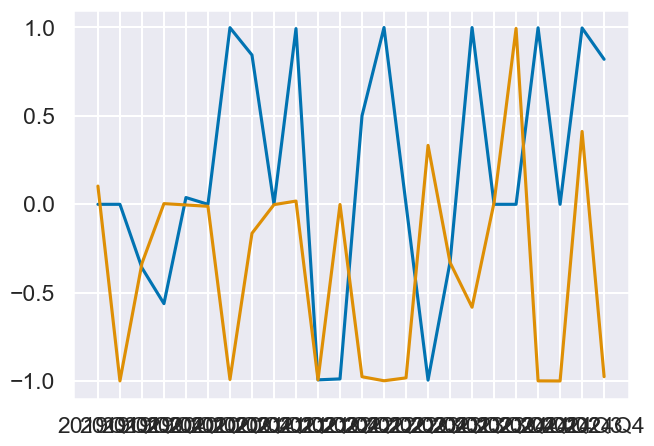

In [155]:
# SCRATCH CELL 2
# Feel free to do your rough work here
# Remember to comment out your code for step 5

#plt.plot(Asian['Quarter'],Asian['asian_sentiment'])
#plt.plot(European.index,European['sentiment'])

# Remember to comment out this code for step 5
# Until then, do not edit this code
#plt.savefig("final_viz.png", dpi=300, bbox_inches="tight")

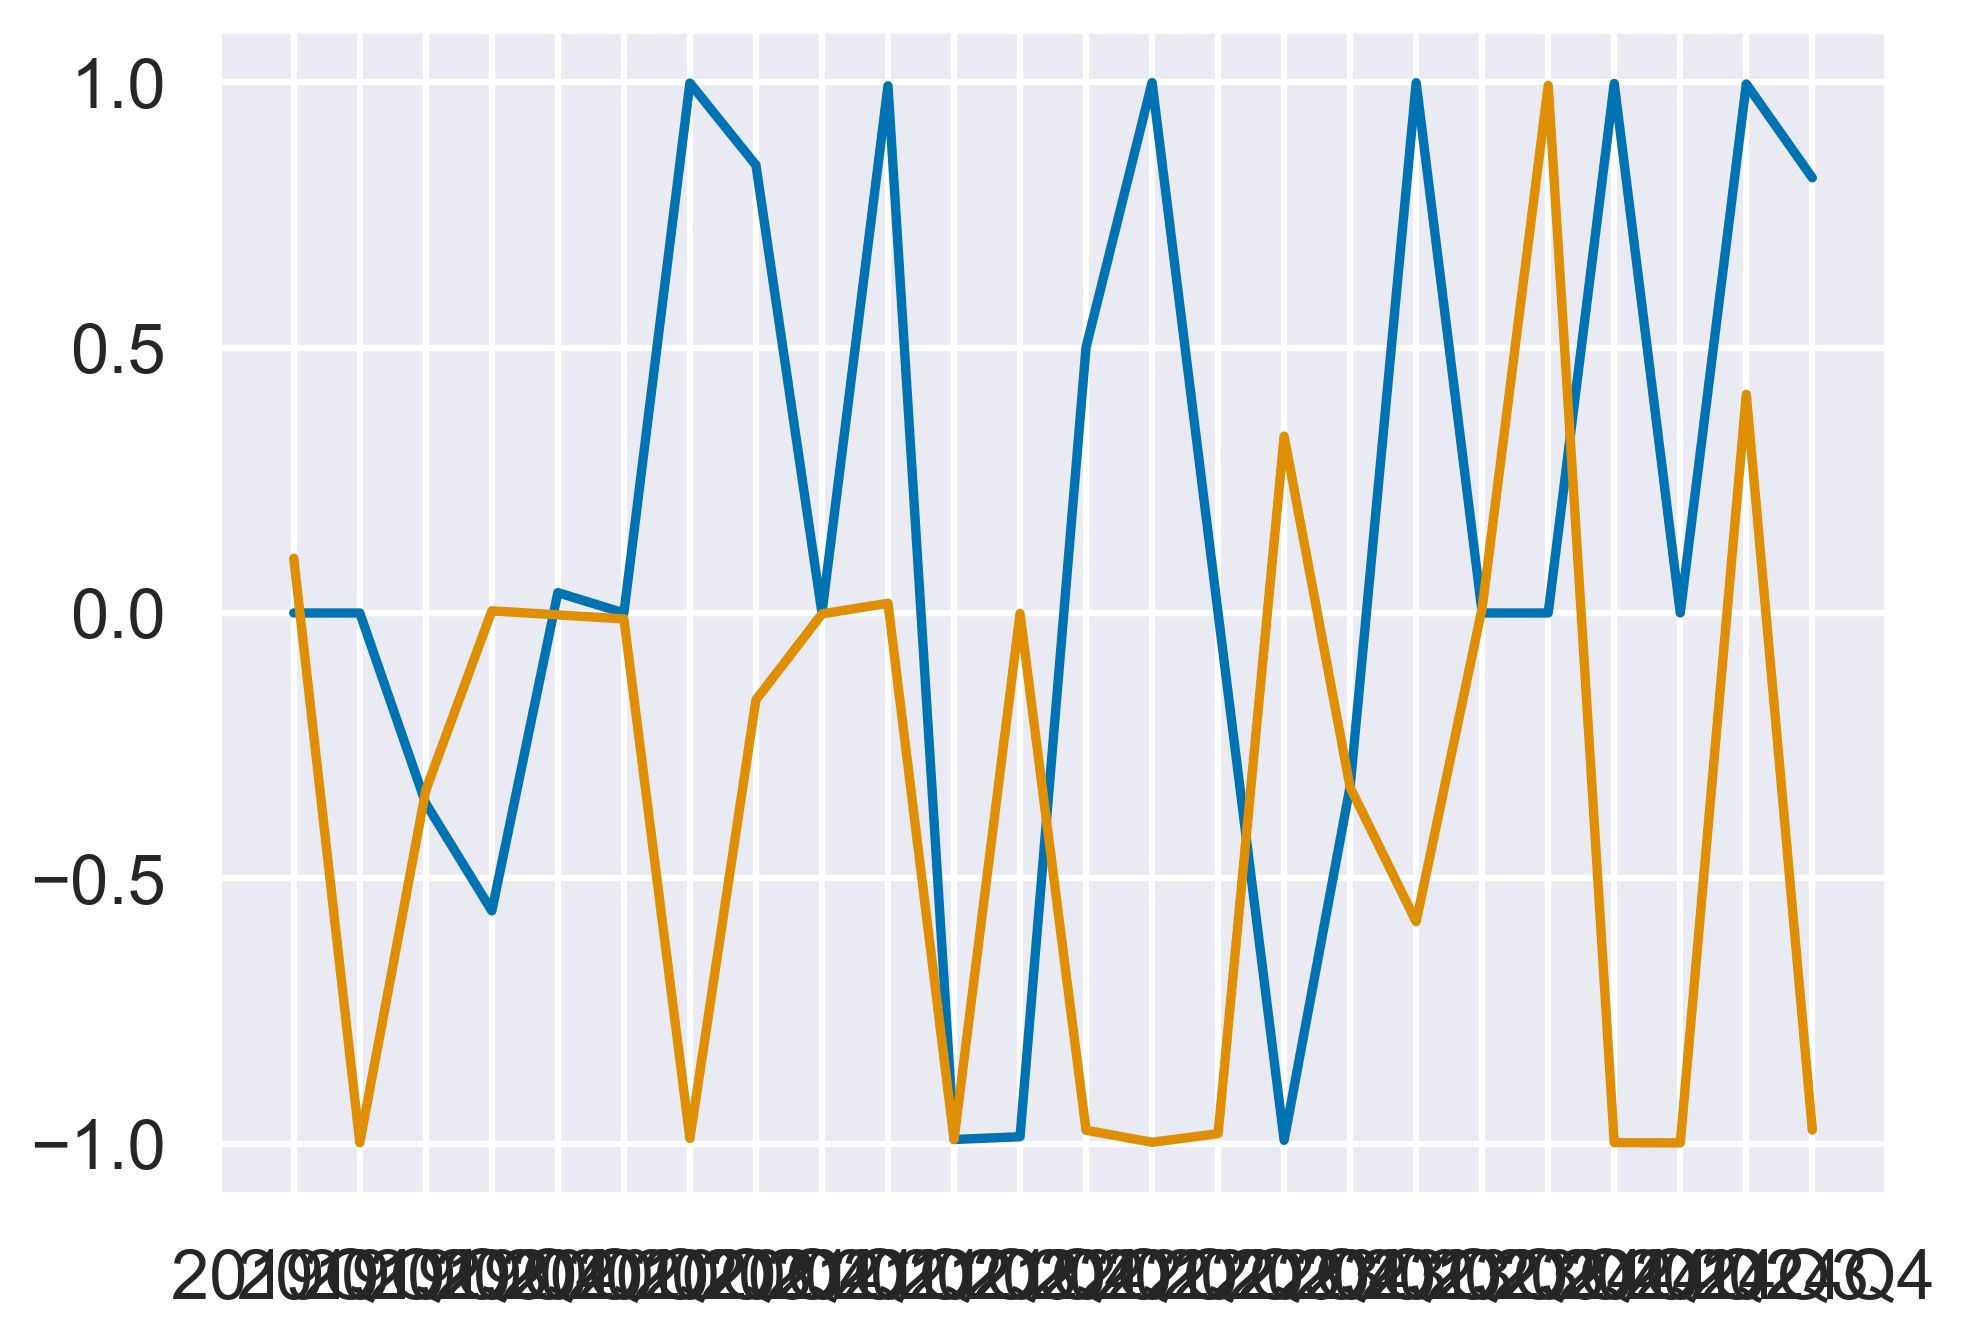

In [156]:
# DO NOT EDIT THIS CELL
# Run this cell and make sure the image that appears is the visualization you want

#from IPython.display import Image

#Image("final_viz.png")

In [157]:
# Set commented_out = True once you have commented out all your code from the scratch cells and the final_df cell

commented_out = True

_According to the chart, there is no evidence of bias against Asians—in fact, the average sentiment score for articles mentioning Asians is higher than that for Europeans. However, the model is unable to distinguish whether the words within a paragraph are used in a positive or negative context, as it only assesses the overall sentiment of the entire paragraph. This introduces significant limitations._

In [160]:
grader.check("q4")

q4 results: All test cases passed!

<!-- END QUESTION -->

<br>

---

### Takeaways

In this homework, we used a language model to evaluate the sentiment of news articles and quantify text data (qualitative data) so that we could perform data analysis on a large set of journalism data. Though we used the [HuggingFace DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english) model, there are thousands of language models available for use, and with rapid innovations in the NLP research space, there are new models frequently being created. In fact, we were using a different model for this homework one year ago, which reflects how quickly the NLP field progresses. 

Different models evaluate sentiment differently. You may have noticed that the DistilBERT model struggles with evaluating neutral sentences and often gives sentences a high polarity score. When evaluating which models to use in your projects, it's useful to test them on small inputs of data to see how they perform, like we did by testing out various sentences! Different models may perform differently (often due to how the model was trained and created), so it's important to understand these differences when deciding what model to use for your data.


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Lily says congratulations! You have finished Homework 3!

<img src = "images/Lily.jpg" width = "400">

### Course Content Feedback

If you have any feedback about this assignment or about any of our other weekly, weekly assignments, lectures, or discussions, please fill out the [Course Content Feedback Form](https://docs.google.com/forms/d/e/1FAIpQLScGQhiTz1qn5gsyYUu1Be5Yz0Z_kplIRR_os8UGMOAO8cc-yQ/viewform?). Your input is valuable in helping us improve the quality and relevance of our content to better meet your needs and expectations!

### Submission Instructions

Below, you will see a cell. Running this cell will automatically generate a zip file with your autograded answers. Once you submit this file to the HW 3 Coding assignment on Pensieve, Pensieve will automatically submit a PDF file with your written answers to the HW 3 Written assignment. If you run into any issues when running this cell, feel free to check this [section](https://ds100.org/debugging-guide/autograder_gradescope/autograder_gradescope.html#why-does-grader.exportrun_teststrue-fail-if-all-previous-tests-passed) in the Data 100 Debugging Guide.

**Important**: Please check that your written responses were generated and submitted correctly to the HW 3 Written Assignment.

**You are responsible for ensuring your submission follows our requirements and that the PDF for HW 3 written answers was generated/submitted correctly. We will not be granting regrade requests nor extensions to submissions that don't follow instructions.** If you encounter any difficulties with submission, please don't hesitate to reach out to staff prior to the deadline.

**Note**: This homework's zip file may take longer to run, so please be patient

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [161]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)